# Pychenette n° 9 : Visualisation de la carte de France avec les villes correspondant aux températures extrêmes moyennes

**Pychenette** est une série de notebooks, en français, courts et originaux avec Python.

**Auteur** : Francis Wolinski

Pour tout commentaire : pychenette[at]yotta-conseil.fr

## L'idée de ce notebook

Inspiré par la canicule de l'été 2026, il est possible de comparer les températures maximales moyennes relevées en France sur les 12 derniers mois (de juillet 2025 à juin 2026l) aux températures mensuelles moyennes de villes du monde entier.

Sources de données :
- *Communes françaises* : https://www.data.gouv.fr/datasets/communes-et-villes-de-france-en-csv-excel-json-parquet-et-feather
- *Températures en France* : https://www.meteociel.fr/
- *Températures des villes du monde* : https://en.wikipedia.org/wiki/List_of_cities_by_average_temperature

On en tire une carte où l'on remplace les noms des villes françaises par leur correspondante. Le procédé pour les températures maximales moyennes vaut aussi pour les températures minimales moyennes.

Nota bene : seules les températures mensuelles moyennes sont prises en comptes et non l'ensemble des données climatiques.

On utilise la librairie **polars**, mais **pandas** est utilisé pour le scrappping des pages web avec la fonction `read_html()`.

In [1]:
# imports
from io import StringIO
from pathlib import Path

import requests

import polars as pl
import pandas as pd
import numpy as np

from scipy.spatial.distance import cdist

import plotly.express as px

## Chargement et préparation des données

### Données des communes françaises

On charge les données des communes françaises situées en métropole.

In [2]:
def load_france_cities():
    france_cities = (pl
                     .scan_csv("communes-france-2026.csv", schema_overrides={"dep_code":pl.String})
                     .filter(pl.col("dep_code").str.len_chars() == 2)  # métropole
                     .select("nom_standard", "dep_code", "latitude_centre", "longitude_centre", "population")
                     .rename({"nom_standard": "Commune", "latitude_centre": "lat", "longitude_centre": "lon"})
                     .collect()
                    )
    return france_cities

france_cities = load_france_cities()
france_cities.head()

Commune,dep_code,lat,lon,population
str,str,f64,f64,i64
"""L'Abergement-Clémenciat""","""01""",46.153,4.926,860
"""L'Abergement-de-Varey""","""01""",46.009,5.428,270
"""Ambérieu-en-Bugey""","""01""",45.961,5.373,15934
"""Ambérieux-en-Dombes""","""01""",45.996,4.912,1906
"""Ambléon""","""01""",45.75,5.594,115


### Chargement et préparation des données météo françaises

Le site https://www.meteociel.fr comporte des pages mensuelles avec pour un ensemble de stations météo les données suivantes :
- Station (*)
- Précipitations mensuelles
- Temp. max. absolue
- Temp. min. absolue
- Temp. max. moyenne (*)
- Temp. min. moyenne (*)
- Ensoleillement

Nous n'utilisons que le nom des stations et les températures extrêmes moyennes (*).

Il faut efectuer des jointures avec les 12 pages mensuelles pour obtenir les données sur la période juillet 2025 - juin 2026.

In [3]:
# chargement des données météo

def load_france_temp_raw():
    france_temp_raw = None
    # de juillet 2025 à juin 2026
    for annee, mois in zip([2025]*6+[2026]*6, list(range(7, 13)) + list(range(1, 7))):
        
        if Path(f"france_{annee}_{mois}.parquet").exists():
            df = pl.read_parquet(f"france_{annee}_{mois}.parquet")
        else:
            var = pd.read_html(f"https://www.meteociel.fr/climatologie/climato.php?ue=0&ua=0&u2=0&ud=0&dt=0&sn=0&mois={mois}&annee={annee}", encoding="latin1", header=0)
            df = pl.from_pandas(var[4])
            for col in df.columns[1:]:
                df = df.with_columns(pl.col(col).str.extract(r"(.*) (?:mm|°C|h)").cast(pl.Float64).alias(col))  # suppression des unités
            df = df.rename({f"{col}":f"{col}_{mois}" for col in df.columns[1:]})
            df.write_parquet(f"france_{annee}_{mois}.parquet")
            
        if france_temp_raw is None:
            france_temp_raw = df
        else:
            france_temp_raw = france_temp_raw.join(df, on="Station")

    return france_temp_raw


def tweak_france_temp(df, indic):
    months = "Jan Feb Mar Apr May Jun Jul Aug Sep Oct Nov Dec".split()
    cols = [col for col in df.columns if (col == "Station") or col.startswith(indic)]
    df = (df
          .select(cols)
          .rename(dict(zip(sorted(cols[1:], key=lambda x: int(x.split("_")[1])), months)))
          .with_columns(ville=pl.col("Station").str.extract(r"(.*) \(.*\)"),
                        departement=pl.col("Station").str.extract(r"\((.*)\)"),
                        moyenne=pl.mean_horizontal(months).round(1))
          .select("ville", "departement", "moyenne", *months)
         )
    return df

france_temp_raw = load_france_temp_raw()
france_temp_min = tweak_france_temp(france_temp_raw, "Temp. min. moyenne_")
france_temp_max = tweak_france_temp(france_temp_raw, "Temp. max. moyenne_")
france_temp_max.head()

ville,departement,moyenne,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Abbeville""","""80""",16.5,7.6,11.0,13.7,17.0,20.6,23.8,23.5,24.5,20.0,15.6,11.8,8.9
"""Agen""","""47""",21.1,10.0,14.9,16.8,22.4,24.8,31.0,29.2,31.7,24.1,21.3,14.8,11.8
"""Aix-en-Provence""","""13""",22.2,11.4,14.7,16.5,23.2,25.2,31.8,32.7,33.3,25.8,21.9,16.1,14.2
"""Ajaccio - Campo dell'Oro""","""2A""",22.5,14.6,16.1,17.9,21.1,23.5,29.0,30.5,30.3,27.8,23.4,19.3,16.8
"""Ajaccio - La Parata""","""2A""",21.9,13.7,15.2,16.9,20.7,22.9,28.6,30.3,30.1,27.0,22.9,18.4,16.2


### Réconciliation des données météo et des communes

Outre la suppression du n° de département dans les noms des communes, on constate qu'il faut corriger les noms de certaines stations pour les faire correspondre avec la base des communes.

Par exemple :
- Paris - Montsouris (75) => Paris
- Dijon / Longvic (21) => Dijon

Il faut également moyenner les données lorsque 2 stations correspondent à une seule commune.

Par exemple :
- Ajaccio - Campo dell'Oro (2A) => Ajaccio
- Ajaccio - La Parata (2A) => Ajaccio
- Toulouse-Blagnac (31) => Toulouse
- Toulouse-Francazal (31) => Toulouse

On tente une correction pour les villes composées d'un seul mot et comportant plus de 5.000 habitants.

In [4]:
def merge_france_temp_cities(france_temp, france_cities):
    months = "Jan Feb Mar Apr May Jun Jul Aug Sep Oct Nov Dec".split()
    # manage missing cities
    single_word_cities = france_cities.filter(pl.col("Commune").str.contains(r"^\w+$"), pl.col("population")>5_000)["Commune"].to_list()
    missing_cities = sorted(set(single_word_cities).difference(set(france_temp["ville"])))
    for city in missing_cities:
        selection = france_temp.filter(pl.col("ville").str.starts_with(city))
        match len(selection):
            case 1:
                selection[0, "ville"] = city
            case 2:
                mean = selection.mean()
                mean[0, "ville"] = city
                mean[0, "departement"] = selection[0, "departement"]
                selection = mean
            case _:
                selection = None
        if selection is not None:
            france_temp = france_temp.vstack(selection)

    france_temp_cities = france_temp.join(france_cities, left_on=["ville", "departement"], right_on=["Commune", "dep_code"], how="inner").drop_nulls()  # jointure sur nom + département
    return france_temp_cities

france_temp_min_cities = merge_france_temp_cities(france_temp_min, france_cities)
france_temp_max_cities = merge_france_temp_cities(france_temp_max, france_cities)
france_temp_max_cities

ville,departement,moyenne,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,lat,lon,population
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64
"""Saint-Quentin""","""02""",17.0,6.5,11.1,14.0,18.0,21.2,26.0,25.4,25.6,20.5,15.8,10.8,8.7,49.847,3.278,52813
"""Vichy""","""03""",19.1,8.7,13.7,14.6,20.2,23.5,30.6,27.6,29.0,21.6,16.7,13.0,10.1,46.13,3.424,25115
"""Briançon""","""05""",16.3,3.9,8.5,9.9,19.0,19.7,27.3,26.5,27.4,20.6,15.4,9.6,7.6,44.9,6.65,11411
"""Embrun""","""05""",18.3,6.1,11.0,13.3,21.1,21.5,28.7,28.1,29.0,22.2,17.5,11.3,10.3,44.58,6.476,6412
"""Antibes""","""06""",22.4,12.9,16.2,17.8,21.6,24.9,29.8,31.7,31.9,27.4,22.7,17.3,14.5,43.588,7.106,77637
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Limoges""","""87""",17.9,7.6,11.5,14.0,20.0,22.1,28.5,25.5,27.6,19.6,17.0,11.4,10.1,45.854,1.249,129937
"""Auxerre""","""89""",18.2,8.2,12.7,14.8,19.8,22.3,29.7,26.6,27.3,20.8,16.4,11.7,8.7,47.794,3.582,35097
"""Belfort""","""90""",16.5,4.4,10.0,12.6,18.0,21.7,27.7,25.2,26.4,19.6,15.0,10.0,6.9,47.647,6.845,45912


### Chargement et préparation des données météo mondiales

On charge les données de la page Wikipédia initulée *List of cities by average temperature*.

In [5]:
def load_world_temp_raw():
    if Path("world_temp.parquet").exists():
        world_temp_raw = pl.read_parquet("world_temp.parquet")
    else:
        headers = {'User-Agent':'Mozilla/5.0'}
        response = requests.get("https://en.wikipedia.org/wiki/List_of_cities_by_average_temperature", headers=headers)
        var = pd.read_html(StringIO(response.text))
        world_temp_raw = pl.concat(map(pl.from_pandas, var))
        world_temp_raw.write_parquet("world_temp.parquet")
    
    return world_temp_raw

def tweak_world(df):
    for col in df.columns[2:-1]:
        df = df.with_columns(pl.col(col).str.extract(r"(.*) \(.*\)").str.replace("−", "-").cast(pl.Float64).alias(col))  # keep Celsius, replace dash by minus sign
    return df

world_temp_raw = load_world_temp_raw()
world_temp = tweak_world(world_temp_raw)
world_temp.head()

Country,City,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Year,Ref.
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""Algeria""","""Algiers""",11.2,11.5,13.6,15.6,18.8,22.6,25.7,26.6,23.9,20.4,15.7,12.6,18.2,"""[1]"""
"""Algeria""","""Tamanrasset""",12.8,15.0,18.1,22.2,26.1,28.9,28.7,28.2,26.5,22.4,17.3,13.9,21.7,"""[2]"""
"""Algeria""","""Reggane""",16.0,18.2,23.1,27.9,32.2,36.4,39.8,38.4,35.5,29.2,22.0,17.8,28.3,"""[3]"""
"""Angola""","""Luanda""",26.7,28.5,28.6,28.2,27.0,23.9,22.1,22.1,23.5,25.2,26.7,26.9,25.8,"""[4]"""
"""Benin""","""Cotonou""",27.3,28.5,28.9,28.6,27.8,26.5,25.8,25.6,26.0,26.7,27.6,27.3,27.2,"""[5]"""


### Réconciliation des données des communes françaises avec les données des villes du monde

Pour chaque commune de française, on recherche la commune du monde avec les 12 températures les plus proches selon la distance euclidienne.

On utilise la fonction `cdist()` de la librairie **scipy**.

In [6]:
def merge_france_temp_cities_world_temp(france_temp_cities, world_temp):
    months = "Jan Feb Mar Apr May Jun Jul Aug Sep Oct Nov Dec".split()
    france_temp_array = france_temp_cities.select(months).to_numpy()
    world_temp_array = world_temp.select(months).to_numpy()

    indices = cdist(world_temp_array, france_temp_array).argsort(axis=0)[0]  # compute all euclidian distances, and keep the indices of the smallest
    cities = pl.Series(world_temp[indices, "City"])
    france_temp_cities = france_temp_cities.with_columns(City=cities)
    
    return france_temp_cities

df_min = merge_france_temp_cities_world_temp(france_temp_min_cities, world_temp)
df_max = merge_france_temp_cities_world_temp(france_temp_max_cities, world_temp)
df_max.head()

ville,departement,moyenne,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,lat,lon,population,City
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,str
"""Saint-Quentin""","""02""",17.0,6.5,11.1,14.0,18.0,21.2,26.0,25.4,25.6,20.5,15.8,10.8,8.7,49.847,3.278,52813,"""Atlanta"""
"""Vichy""","""03""",19.1,8.7,13.7,14.6,20.2,23.5,30.6,27.6,29.0,21.6,16.7,13.0,10.1,46.13,3.424,25115,"""El Paso"""
"""Briançon""","""05""",16.3,3.9,8.5,9.9,19.0,19.7,27.3,26.5,27.4,20.6,15.4,9.6,7.6,44.9,6.65,11411,"""Charlotte"""
"""Embrun""","""05""",18.3,6.1,11.0,13.3,21.1,21.5,28.7,28.1,29.0,22.2,17.5,11.3,10.3,44.58,6.476,6412,"""El Paso"""
"""Antibes""","""06""",22.4,12.9,16.2,17.8,21.6,24.9,29.8,31.7,31.9,27.4,22.7,17.3,14.5,43.588,7.106,77637,"""Mexicali"""


### Production de cartes

#### Carte avec les villes correspondant aux températures moyennes maximales

Avec ce procédé, la grande majorité des villes françaises se retrouvent alignées sur le sud des États-Unis et le nord du Mexique !

On trouve aussi Marseille à la place de Dunkerque...

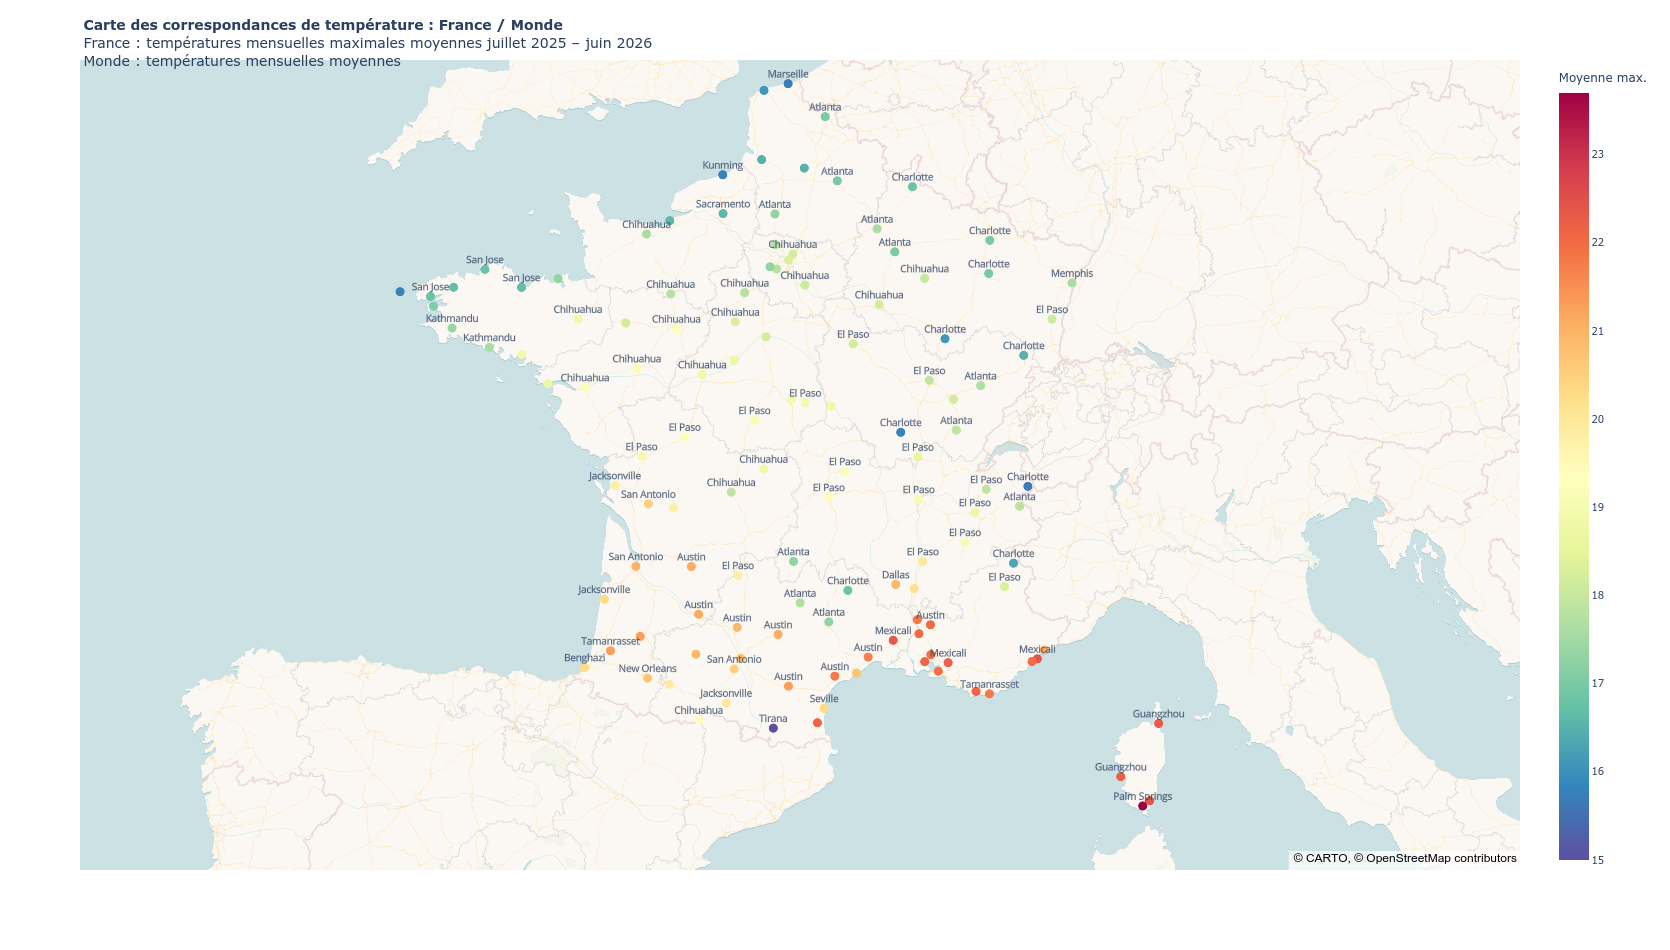

In [7]:
fig = px.scatter_map(df_max.to_pandas(), lat="lat", lon="lon", text="City", color="moyenne", color_continuous_scale="Spectral_r",
                 width=1050, height=950, zoom=5.2)
fig.update_traces(
    marker=dict(size=10),
    mode="markers+text",      # key part: adds text mode alongside markers
    textposition="top center" # or "bottom center", "middle right", etc.
)
fig.update_layout(map_style="carto-voyager-nolabels",
                  coloraxis_colorbar_title_text = 'Moyenne max.',
                  showlegend=False, title={'text': '<b>Carte des correspondances de température : France / Monde</b><br>France : températures mensuelles maximales moyennes juillet 2025 – juin 2026<br>Monde : températures mensuelles moyennes'}, font=dict(size=10))
fig

#### Carte avec les villes correspondant aux températures moyennes minimales

Avec ce procédé, la grande majorité des villes françaises se retrouvent alignées sur le nord de l'Europe !

On trouve aussi Paris à la place de Bordeaux ou Calvi...

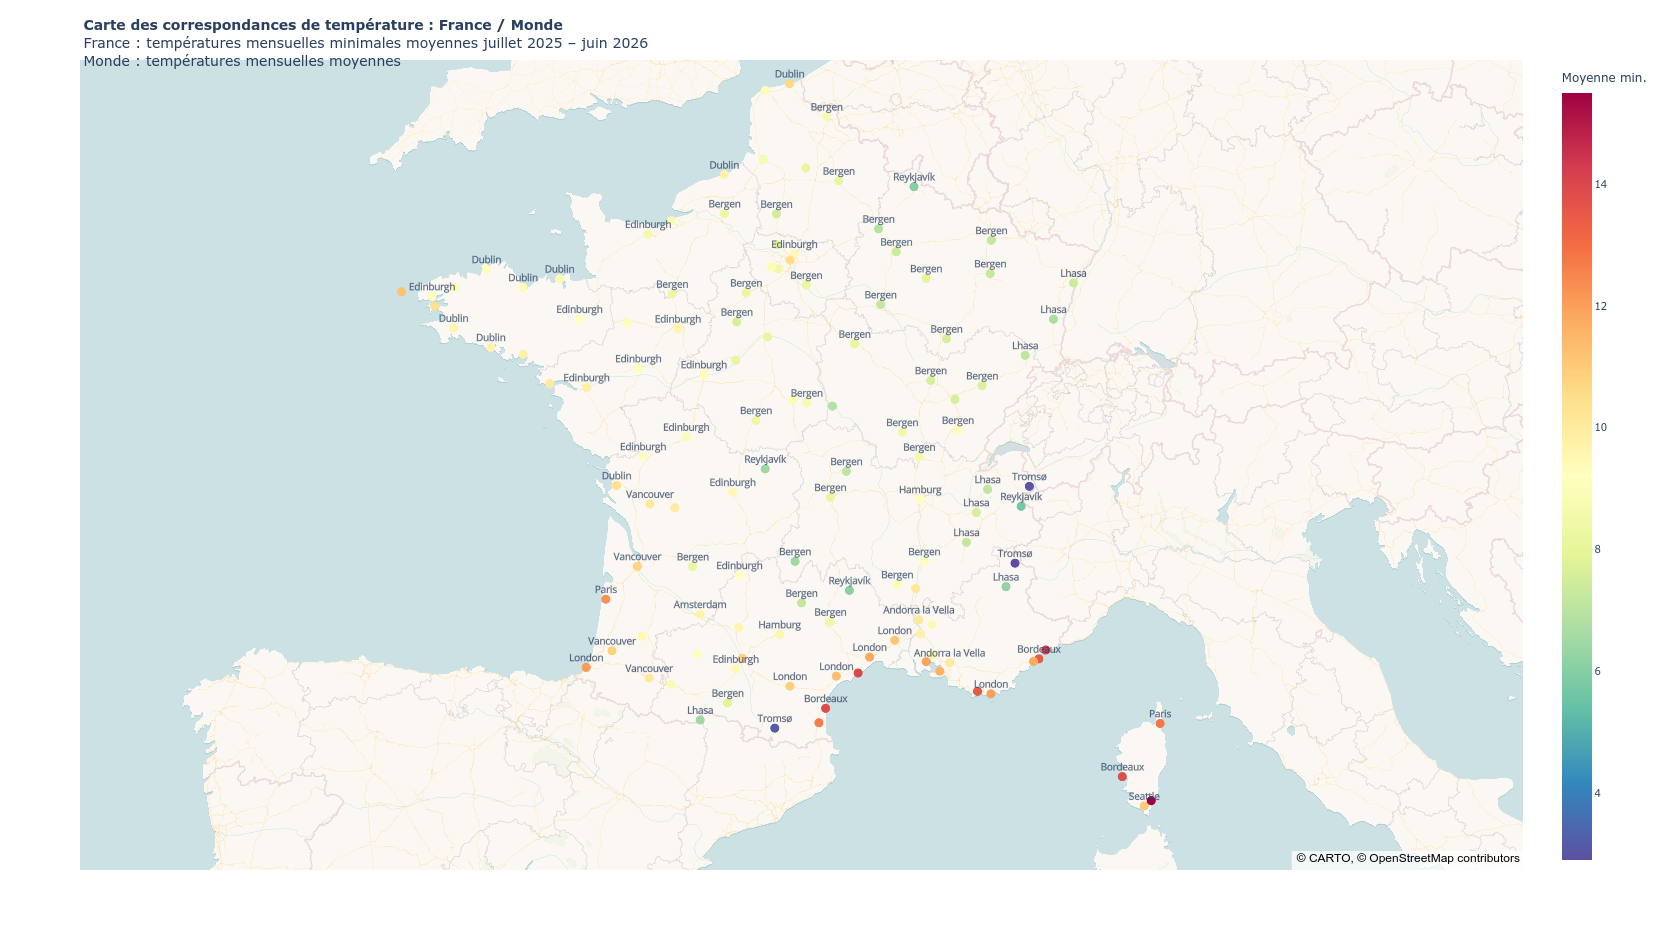

In [8]:
fig = px.scatter_map(df_min.to_pandas(), lat="lat", lon="lon", text="City", color="moyenne", color_continuous_scale="Spectral_r",
                 width=1050, height=950, zoom=5.2)
fig.update_traces(
    marker=dict(size=10),
    mode="markers+text",      # key part: adds text mode alongside markers
    textposition="top center" # or "bottom center", "middle right", etc.
)
fig.update_layout(map_style="carto-voyager-nolabels",
                  coloraxis_colorbar_title_text = 'Moyenne min.',
                  showlegend=False, title={'text': '<b>Carte des correspondances de température : France / Monde</b><br>France : températures mensuelles minimales moyennes juillet 2025 – juin 2026<br>Monde : températures mensuelles moyennes'}, font=dict(size=10))
fig